# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:

train_url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'

# Load dataset
df = pd.read_csv(train_url)


print(f"Dataset shape: {df.shape}")
print(f"\nDataset columns:\n{df.columns.tolist()}")

Dataset shape: (891, 12)

Dataset columns:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

EXPLORATORY DATA ANALYSIS - TITANIC DATASET

Dataset shape: (891, 15)
Dataset columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']
MISSING VALUES ANALYSIS
     Column  Missing Count  Missing %
       deck            688  77.216611
        age            177  19.865320
   embarked              2   0.224467
embark_town              2   0.224467


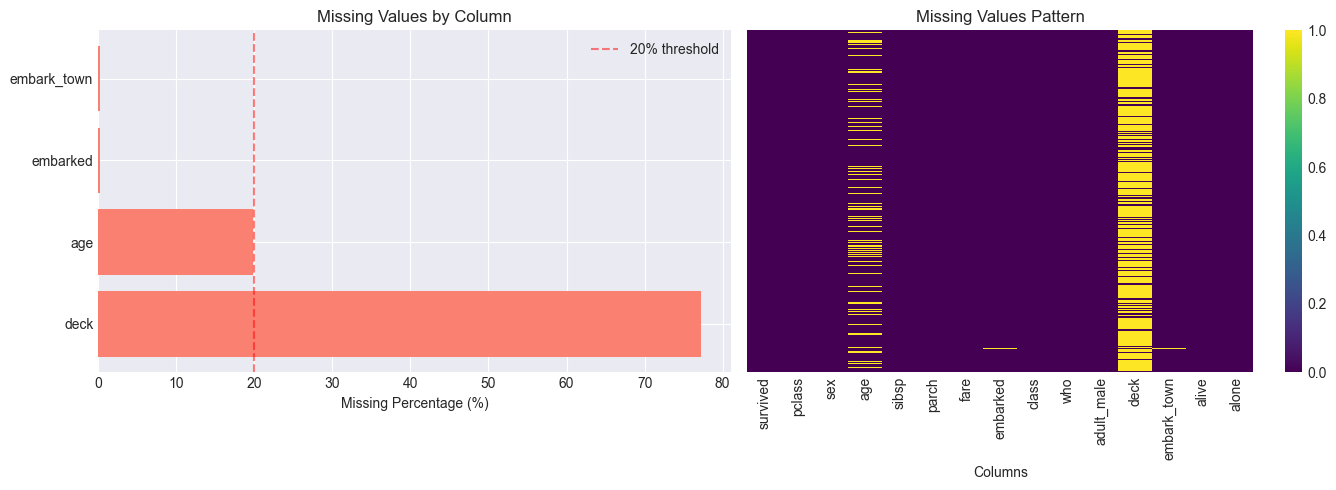

TARGET VARIABLE ANALYSIS (Survived)

Distribution:
  Not Survived (0): 549 (61.6%)
  Survived (1):    342 (38.4%)


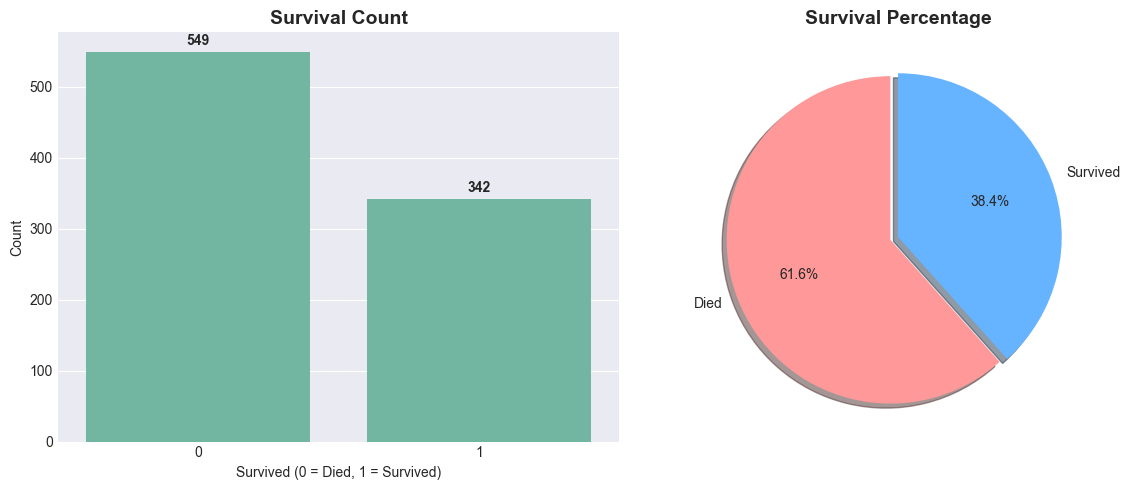

CATEGORICAL FEATURES ANALYSIS

SEX Analysis:
----------------------------------------
sex
male      577
female    314


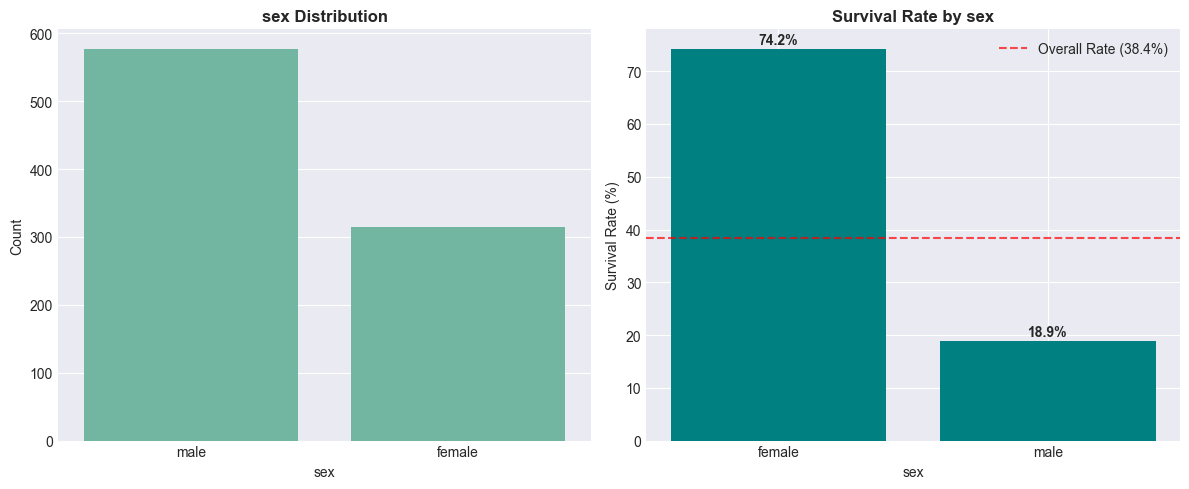


EMBARKED Analysis:
----------------------------------------
embarked
S    644
C    168
Q     77


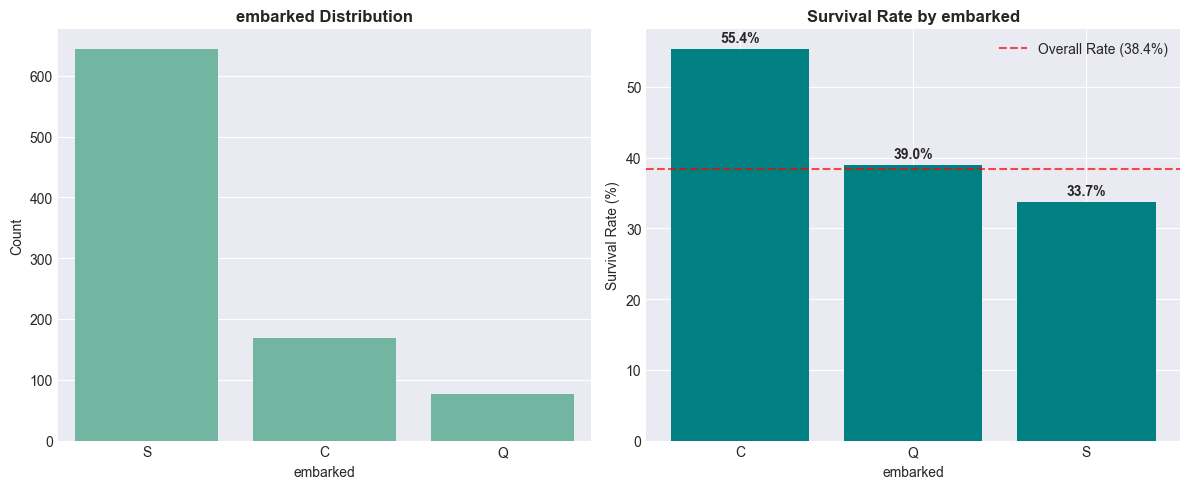


PCLASS Analysis:
----------------------------------------
pclass
3    491
1    216
2    184


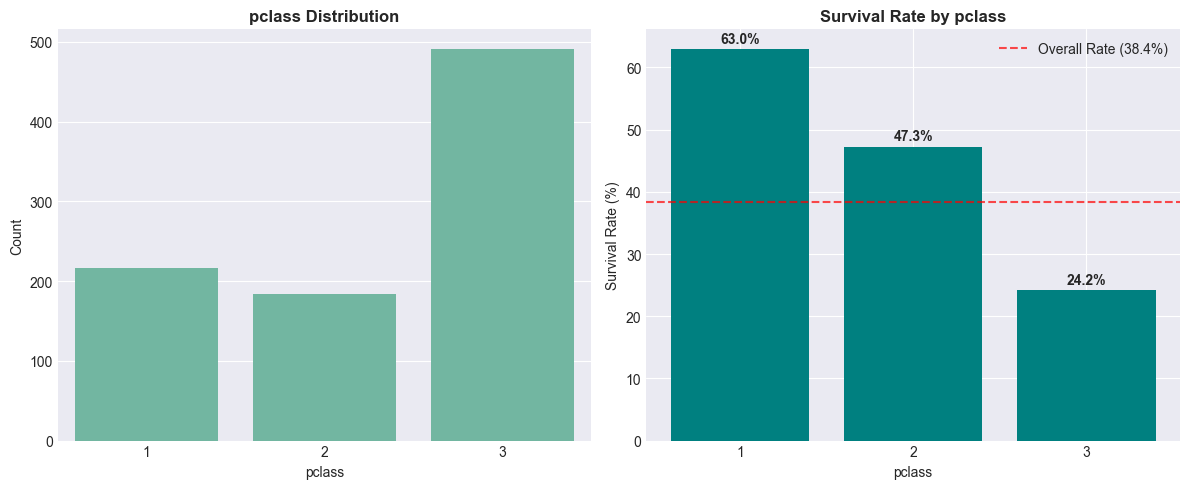

NUMERICAL FEATURES ANALYSIS

Statistical Summary (grouped by Survival):

AGE:
          count       mean        std   min   25%   50%   75%   max
survived                                                           
0         424.0  30.626179  14.172110  1.00  21.0  28.0  39.0  74.0
1         290.0  28.343690  14.950952  0.42  19.0  28.0  36.0  80.0

FARE:
          count       mean        std  min      25%   50%   75%       max
survived                                                                 
0         549.0  22.117887  31.388207  0.0   7.8542  10.5  26.0  263.0000
1         342.0  48.395408  66.596998  0.0  12.4750  26.0  57.0  512.3292

SIBSP:
          count      mean       std  min  25%  50%  75%  max
survived                                                    
0         549.0  0.553734  1.288399  0.0  0.0  0.0  1.0  8.0
1         342.0  0.473684  0.708688  0.0  0.0  0.0  1.0  4.0

PARCH:
          count      mean       std  min  25%  50%  75%  max
survived                  

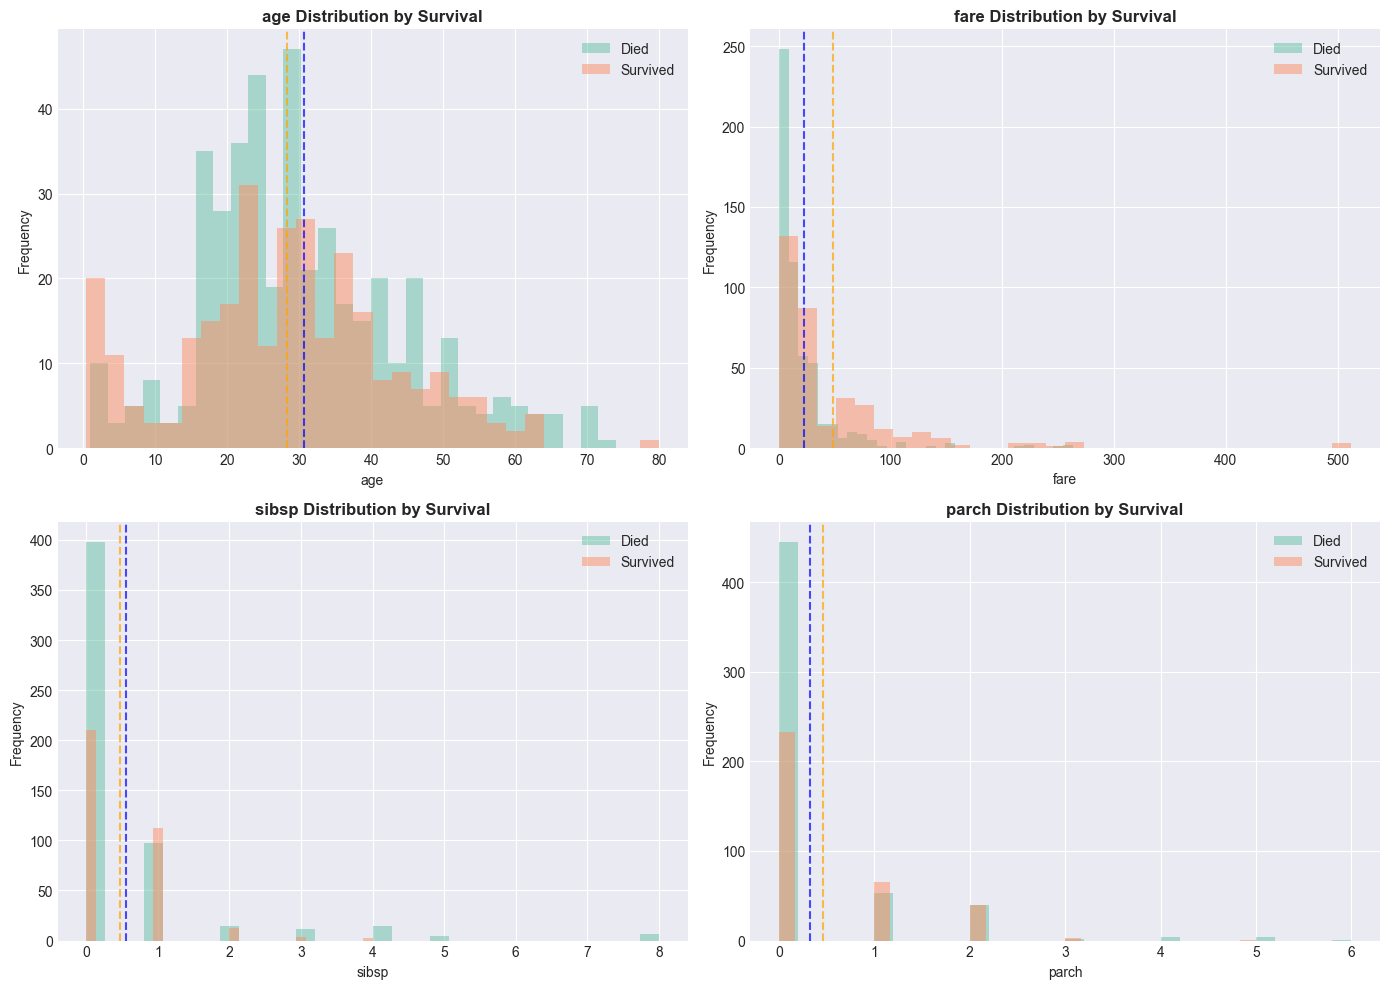

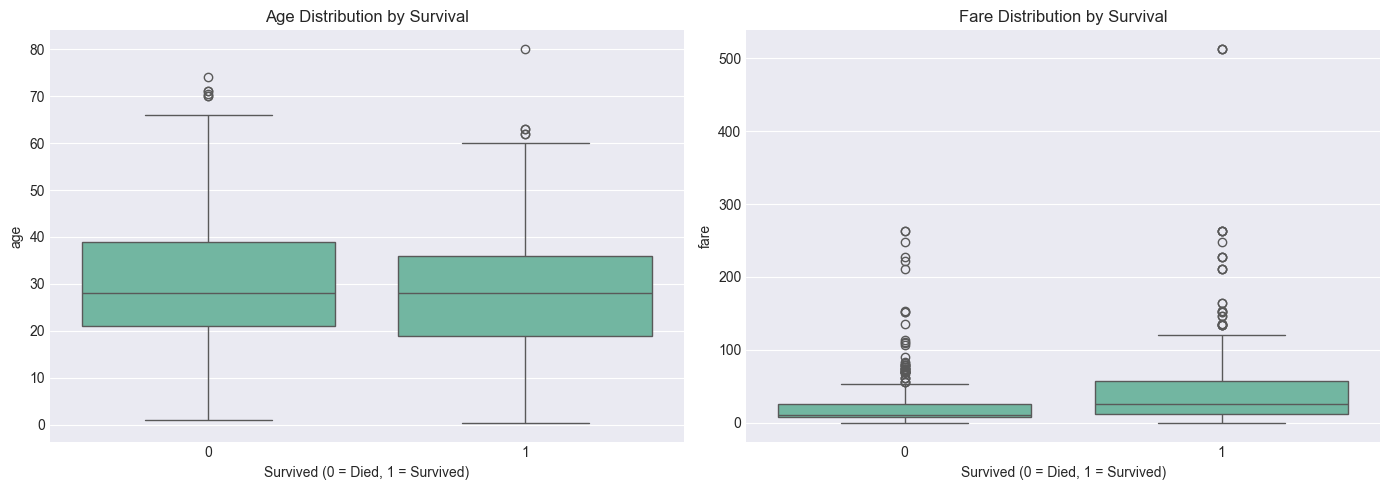

CORRELATION ANALYSIS

Correlation with Survival:
survived    1.000000
fare        0.257307
parch       0.081629
sibsp      -0.035322
age        -0.077221
pclass     -0.338481


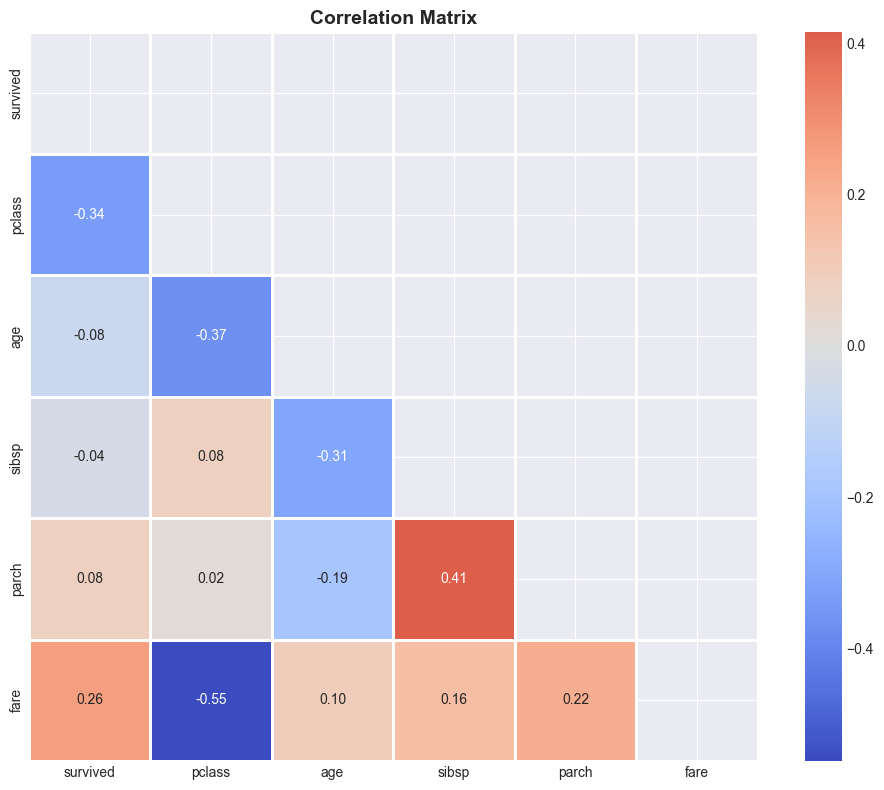

MULTIVARIATE ANALYSIS


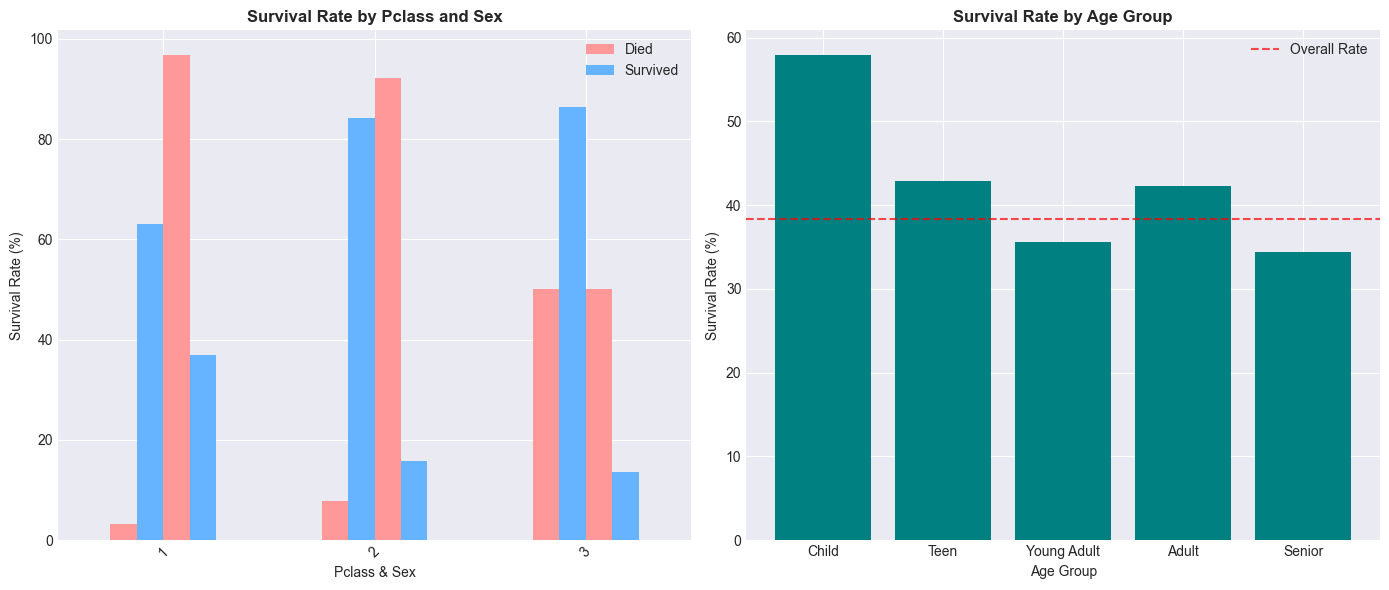

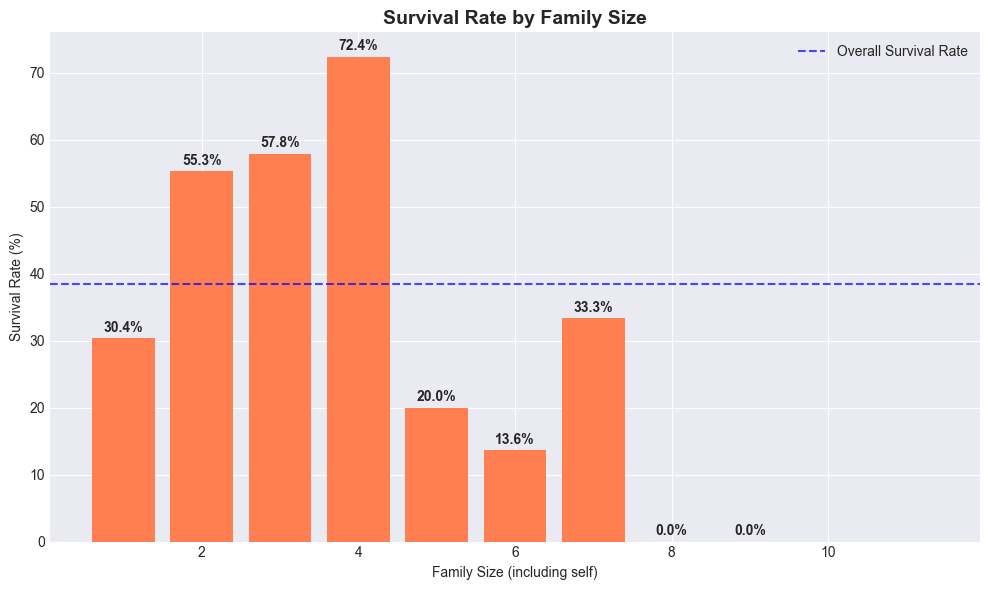

OUTLIER DETECTION (IQR Method)

age:
  Jumlah outliers: 11
  Batas bawah: -6.69
  Batas atas: 64.81

fare:
  Jumlah outliers: 116
  Batas bawah: -26.72
  Batas atas: 65.63

sibsp:
  Jumlah outliers: 46
  Batas bawah: -1.50
  Batas atas: 2.50

parch:
  Jumlah outliers: 213
  Batas bawah: 0.00
  Batas atas: 0.00
EDA SELESAI.


In [3]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10


df = sns.load_dataset('titanic')

print("EXPLORATORY DATA ANALYSIS - TITANIC DATASET")


print(f"\nDataset shape: {df.shape}")
print(f"Dataset columns: {df.columns.tolist()}")


# 1. MISSING VALUES ANALYSIS


print("MISSING VALUES ANALYSIS")


missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing Count': df.isnull().sum().values,
    'Missing %': (df.isnull().sum().values / len(df)) * 100
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print(missing_df.to_string(index=False))

# Visualisasi missing values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if len(missing_df) > 0:
    axes[0].barh(missing_df['Column'], missing_df['Missing %'], color='salmon')
    axes[0].set_xlabel('Missing Percentage (%)')
    axes[0].set_title('Missing Values by Column')
    axes[0].axvline(x=20, linestyle='--', color='red', alpha=0.5, label='20% threshold')
    axes[0].legend()

sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap='viridis', ax=axes[1])
axes[1].set_title('Missing Values Pattern')
axes[1].set_xlabel('Columns')

plt.tight_layout()
plt.show()


# 2. TARGET VARIABLE ANALYSIS


print("TARGET VARIABLE ANALYSIS (Survived)")


survival_counts = df['survived'].value_counts()
survival_percent = df['survived'].value_counts(normalize=True) * 100

print(f"\nDistribution:")
print(f"  Not Survived (0): {survival_counts[0]} ({survival_percent[0]:.1f}%)")
print(f"  Survived (1):    {survival_counts[1]} ({survival_percent[1]:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df, x='survived', ax=axes[0])
axes[0].set_title('Survival Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Survived (0 = Died, 1 = Survived)')
axes[0].set_ylabel('Count')
for i, v in enumerate(survival_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

colors = ['#ff9999', '#66b3ff']
axes[1].pie(survival_counts.values, labels=['Died', 'Survived'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            explode=(0.05, 0), shadow=True)
axes[1].set_title('Survival Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


# 3. CATEGORICAL FEATURES ANALYSIS


print("CATEGORICAL FEATURES ANALYSIS")


categorical_cols = ['sex', 'embarked', 'pclass']
for col in categorical_cols:
    if col in df.columns:
        print(f"\n{col.upper()} Analysis:")
        print("-" * 40)

        counts = df[col].value_counts()
        print(counts.to_string())

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        sns.countplot(data=df, x=col, ax=axes[0])
        axes[0].set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
        axes[0].set_xlabel(col)
        axes[0].set_ylabel('Count')

        survival_rate = df.groupby(col)['survived'].mean() * 100
        axes[1].bar(survival_rate.index.astype(str), survival_rate.values, color='teal')
        axes[1].set_title(f'Survival Rate by {col}', fontsize=12, fontweight='bold')
        axes[1].set_xlabel(col)
        axes[1].set_ylabel('Survival Rate (%)')
        axes[1].axhline(y=38.4, linestyle='--', color='red', alpha=0.7, label='Overall Rate (38.4%)')
        axes[1].legend()

        for i, v in enumerate(survival_rate.values):
            axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

        plt.tight_layout()
        plt.show()


# 4. NUMERICAL FEATURES ANALYSIS


print("NUMERICAL FEATURES ANALYSIS")


numerical_cols = ['age', 'fare', 'sibsp', 'parch']

print("\nStatistical Summary (grouped by Survival):")
for col in numerical_cols:
    if col in df.columns:
        print(f"\n{col.upper()}:")
        stats = df.groupby('survived')[col].describe()
        print(stats)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    if col in df.columns:
        for survival_status in [0, 1]:
            subset = df[df['survived'] == survival_status][col].dropna()
            label = 'Died' if survival_status == 0 else 'Survived'
            axes[idx].hist(subset, bins=30, alpha=0.5, label=label)

        axes[idx].set_title(f'{col} Distribution by Survival', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')
        axes[idx].legend()

        mean_died = df[df['survived'] == 0][col].mean()
        mean_survived = df[df['survived'] == 1][col].mean()
        axes[idx].axvline(mean_died, color='blue', linestyle='--', alpha=0.7)
        axes[idx].axvline(mean_survived, color='orange', linestyle='--', alpha=0.7)

for idx in range(len(numerical_cols), 4):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='survived', y='age', ax=axes[0])
axes[0].set_title('Age Distribution by Survival')
axes[0].set_xlabel('Survived (0 = Died, 1 = Survived)')

sns.boxplot(data=df, x='survived', y='fare', ax=axes[1])
axes[1].set_title('Fare Distribution by Survival')
axes[1].set_xlabel('Survived (0 = Died, 1 = Survived)')

plt.tight_layout()
plt.show()


# 5. CORRELATION ANALYSIS


print("CORRELATION ANALYSIS")


numeric_features = df.select_dtypes(include=[np.number]).columns
correlation_with_target = df[numeric_features].corr()['survived'].sort_values(ascending=False)

print("\nCorrelation with Survival:")
print(correlation_with_target.to_string())

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(df[numeric_features].corr(), dtype=bool))
sns.heatmap(df[numeric_features].corr(),
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=1,
            mask=mask)
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# 6. MULTIVARIATE ANALYSIS

print("MULTIVARIATE ANALYSIS")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pclass vs Sex vs Survival
pclass_sex_survival = pd.crosstab([df['pclass'], df['sex']],
                                   df['survived'],
                                   normalize='index') * 100
pclass_sex_survival.unstack().plot(kind='bar', ax=axes[0], color=['#ff9999', '#66b3ff'])
axes[0].set_title('Survival Rate by Pclass and Sex', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Pclass & Sex')
axes[0].set_ylabel('Survival Rate (%)')
axes[0].legend(['Died', 'Survived'])
axes[0].tick_params(axis='x', rotation=45)

# Age group analysis
df['AgeGroup'] = pd.cut(df['age'],
                        bins=[0, 12, 18, 30, 50, 80],
                        labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'])
age_group_survival = df.groupby('AgeGroup', observed=True)['survived'].mean() * 100
axes[1].bar(age_group_survival.index.astype(str), age_group_survival.values, color='teal')
axes[1].set_title('Survival Rate by Age Group', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].axhline(y=38.4, linestyle='--', color='red', alpha=0.7, label='Overall Rate')
axes[1].legend()

plt.tight_layout()
plt.show()

# Family size analysis
df['FamilySize'] = df['sibsp'] + df['parch'] + 1
family_survival = df.groupby('FamilySize')['survived'].mean() * 100

plt.figure(figsize=(10, 6))
plt.bar(family_survival.index, family_survival.values, color='coral')
plt.axhline(y=38.4, linestyle='--', color='blue', alpha=0.7, label='Overall Survival Rate')
plt.xlabel('Family Size (including self)')
plt.ylabel('Survival Rate (%)')
plt.title('Survival Rate by Family Size', fontsize=14, fontweight='bold')
plt.legend()
for i, v in enumerate(family_survival.values):
    plt.text(i + 1, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


# 7. OUTLIER DETECTION


print("OUTLIER DETECTION (IQR Method)")


def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

for col in numerical_cols:
    if col in df.columns:
        data_clean = df.dropna(subset=[col])
        if len(data_clean) > 0:
            n_outliers, lower, upper = detect_outliers_iqr(data_clean, col)
            print(f"\n{col}:")
            print(f"  Jumlah outliers: {n_outliers}")
            print(f"  Batas bawah: {lower:.2f}")
            print(f"  Batas atas: {upper:.2f}")




df = df.drop(['AgeGroup', 'FamilySize'], axis=1)

print("EDA SELESAI.")


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [4]:
df = sns.load_dataset('titanic')

print("Struktur dataset:")
print(df.columns.tolist())
print("")


print("[TAHAPAN 1] HANDLING MISSING VALUES")
print("-" * 40)

print("Missing values sebelum ditangani:")
print(df.isnull().sum())


if 'deck' in df.columns:
    df['has_deck'] = df['deck'].notna().astype(int)
    df = df.drop('deck', axis=1)
    print("- Deck: dropped, created 'has_deck' feature")
elif 'cabin' in df.columns:
    df['has_cabin'] = df['cabin'].notna().astype(int)
    df = df.drop('cabin', axis=1)
    print("- Cabin: dropped, created 'has_cabin' feature")
else:
    print("- Tidak ada kolom cabin/deck, skip")


if 'embarked' in df.columns:
    df['embarked'] = df['embarked'].fillna('S')
    print("- Embarked: filled with 'S' (mode)")


def impute_age(cols):
    age = cols[0]
    pclass = cols[1]
    sex = cols[2]
    
    if pd.isnull(age):
        age_by_group = {
            (1, 'male'): 40, (1, 'female'): 35,
            (2, 'male'): 30, (2, 'female'): 28,
            (3, 'male'): 25, (3, 'female'): 22
        }
        return age_by_group.get((pclass, sex), df['age'].median())
    return age

df['age'] = df[['age', 'pclass', 'sex']].apply(impute_age, axis=1)
print("- Age: imputed with median grouped by Pclass and Sex")

print("\nMissing values setelah ditangani:")
print(df.isnull().sum())

# TAHAPAN 2: MENGHAPUS DATA DUPLIKAT
print("\n[TAHAPAN 2] MENGHAPUS DATA DUPLIKAT")
print("-" * 40)

duplicate_count = df.duplicated().sum()
print(f"Jumlah data duplikat: {duplicate_count}")

if duplicate_count > 0:
    df = df.drop_duplicates()
    print(f"Data duplikat dihapus. Dataset shape sekarang: {df.shape}")
else:
    print("Tidak ada data duplikat. Dataset tetap.")

# TAHAPAN 3: DETEKSI DAN PENANGANAN OUTLIER
print("\n[TAHAPAN 3] DETEKSI & PENANGANAN OUTLIER")
print("-" * 40)

def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

numerical_cols = ['age', 'fare', 'sibsp', 'parch']
existing_num_cols = [col for col in numerical_cols if col in df.columns]

print("Outlier detection sebelum penanganan:")
for col in existing_num_cols:
    n_outliers, lower, upper = detect_outliers_iqr(df, col)
    print(f"  {col}: {n_outliers} outliers ({(n_outliers/len(df))*100:.1f}%)")

if 'fare' in df.columns:
    print("\nPenanganan outlier untuk 'fare' (capping at 95th percentile):")
    fare_95th = df['fare'].quantile(0.95)
    fare_outliers_before = (df['fare'] > fare_95th).sum()
    df['fare'] = df['fare'].clip(upper=fare_95th)
    print(f"  - Fare outliers above 95th percentile ({fare_95th:.2f}): {fare_outliers_before} -> capped")

if 'age' in df.columns:
    age_95th = df['age'].quantile(0.95)
    age_99th = df['age'].quantile(0.99)
    age_outliers_before = (df['age'] > age_95th).sum()
    df['age'] = df['age'].clip(upper=age_99th)
    print(f"  - Age outliers above 99th percentile ({age_99th:.2f}): {age_outliers_before} -> capped")

print("\nOutlier detection setelah penanganan:")
for col in existing_num_cols:
    n_outliers, lower, upper = detect_outliers_iqr(df, col)
    print(f"  {col}: {n_outliers} outliers ({(n_outliers/len(df))*100:.1f}%)")

# TAHAPAN 4: FEATURE ENGINEERING & BINNING
print("\n[TAHAPAN 4] FEATURE ENGINEERING & BINNING")
print("-" * 40)


if 'name' in df.columns:
    df['title'] = df['name'].apply(lambda x: x.split(',')[1].split('.')[0].strip())

    title_mapping = {
        'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master',
        'Dr': 'Rare', 'Rev': 'Rare', 'Col': 'Rare', 'Major': 'Rare',
        'Mlle': 'Miss', 'Countess': 'Rare', 'Ms': 'Miss', 'Lady': 'Rare',
        'Jonkheer': 'Rare', 'Don': 'Rare', 'Dona': 'Rare', 'Mme': 'Mrs',
        'Capt': 'Rare', 'Sir': 'Rare'
    }
    df['title'] = df['title'].map(title_mapping)
    print("- Title extracted from Name: Mr, Mrs, Miss, Master, Rare")


if 'sibsp' in df.columns and 'parch' in df.columns:
    df['FamilySize'] = df['sibsp'] + df['parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
    print("- FamilySize and IsAlone created")

if 'age' in df.columns:
    df['AgeGroup'] = pd.cut(df['age'], 
                            bins=[0, 12, 18, 30, 45, 60, 100], 
                            labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Middle Age', 'Senior'])
    print("- AgeGroup binning: Child, Teen, Young Adult, Adult, Middle Age, Senior")


if 'fare' in df.columns:
    df['FareGroup'] = pd.qcut(df['fare'], 4, labels=['Low', 'Medium', 'High', 'Very High'])
    print("- FareGroup binning: Low, Medium, High, Very High (quartiles)")

# TAHAPAN 5: ENCODING DATA KATEGORIKAL
print("\n[TAHAPAN 5] ENCODING DATA KATEGORIKAL")
print("-" * 40)


if 'sex' in df.columns:
    df = pd.get_dummies(df, columns=['sex'], drop_first=True)
    print("- One-Hot Encoding: sex_male")
if 'embarked' in df.columns:
    df = pd.get_dummies(df, columns=['embarked'], drop_first=True)
    print("- One-Hot Encoding: embarked_Q, embarked_S")

if 'title' in df.columns:
    title_dummies = pd.get_dummies(df['title'], prefix='title')
    df = pd.concat([df, title_dummies], axis=1)
    df = df.drop('title', axis=1)
    print(f"- Title dummies: {list(title_dummies.columns)}")


if 'AgeGroup' in df.columns:
    agegroup_dummies = pd.get_dummies(df['AgeGroup'], prefix='agegroup')
    df = pd.concat([df, agegroup_dummies], axis=1)
    df = df.drop('AgeGroup', axis=1)
    print(f"- AgeGroup dummies: {list(agegroup_dummies.columns)}")


if 'FareGroup' in df.columns:
    faregroup_dummies = pd.get_dummies(df['FareGroup'], prefix='faregroup')
    df = pd.concat([df, faregroup_dummies], axis=1)
    df = df.drop('FareGroup', axis=1)
    print(f"- FareGroup dummies: {list(faregroup_dummies.columns)}")

# TAHAPAN 6: NORMALISASI/STANDARISASI FITUR
print("\n[TAHAPAN 6] NORMALISASI/STANDARISASI FITUR")


from sklearn.preprocessing import StandardScaler


numerical_features = ['age', 'fare', 'sibsp', 'parch', 'FamilySize']
existing_num_features = [col for col in numerical_features if col in df.columns]

if existing_num_features:
    print(f"Fitur numerik yang akan distandarisasi: {existing_num_features}")
    print("\nStatistik sebelum standarisasi:")
    print(df[existing_num_features].describe().loc[['mean', 'std']])

    scaler = StandardScaler()
    df[existing_num_features] = scaler.fit_transform(df[existing_num_features])

    print("\nStatistik setelah standarisasi (StandardScaler):")
    print(df[existing_num_features].describe().loc[['mean', 'std']])



# Preview data setelah preprocessing
print("\nPreview data setelah preprocessing (5 baris pertama):")
print(df.head())

Struktur dataset:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

[TAHAPAN 1] HANDLING MISSING VALUES
----------------------------------------
Missing values sebelum ditangani:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64
- Deck: dropped, created 'has_deck' feature
- Embarked: filled with 'S' (mode)
- Age: imputed with median grouped by Pclass and Sex

Missing values setelah ditangani:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
has_deck       0
dtyp